# Imports

In [3]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [378]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


In [379]:
df_tr, dstrb_idx = dsp.load_and_process_session(SESSIONS[0])
perturb_td = pyal.restrict_to_interval(
    df_tr,
    start_point_name="idx_sol_on",
    rel_start=-200,
    rel_end=300,
)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['MOp_spikes', 'all_spikes', 'CP_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(


Resulting MOp_spikes ephys data shape is (NxT): (199, 48000)
Resulting all_spikes ephys data shape is (NxT): (96, 48000)
Resulting CP_spikes ephys data shape is (NxT): (199, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (149, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (72, 48000)
Skipped 34 trials
Otsu immobility threshold: 4.4447
Dropped 160 of 353 rows (45.33%).


/tmp/ipykernel_2234714/3151376078.py:2: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(


In [386]:
td_potent_null = subspaces.compute_potent_null_td(
    td_=perturb_td_shuff,
    signal_x='MOp_rates_pca',
    signal_y='CP_rates_pca',
    origin_rank=25,
    target_rank=30,
    n_iter=1
)

Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.1726. Optimal rank: 8
Using 1 iterations...
	Iter: 0. Prediction R2 = 0.0304
Diagnostics:
	Total MOp_rates_pca var:         9459.21
	Fraction Potent (dim: 8) var:    0.203
	Fraction Null (dim: 9) var:      0.187
	Fraction Null init var:          0.354
	Fraction MOp_rates_pca var:      0.557


In [152]:
from sklearn.model_selection import StratifiedKFold

def majority_class_chance_levels_from_counts(counts):
    """
    counts_dict: {class_label: count, ...}
    Returns:
      N, majority_chance, prior_weighted_chance, uniform_chance
    """
    N = counts.sum()

    majority_chance = counts.max() / N

    return majority_chance

def naive_opt_alpha(alpha_range, cv_scores):
    """
    Select the alpha value with the highest cross-validated test score

    Parameters
    ----------
    alpha_range : array-like
        candidate alpha values
    cv_scores : array-like
        cross-validated test scores corresponding
        to the values in alpha_range

    Returns
    -------
    optimal alpha : float
    """
    means = [np.mean(sc) for sc in cv_scores]
    return alpha_range[np.argmax(means)]


def opt_ridge_alpha(X, y, n_alpha=50, cv=KFold(5), scorer=decode.get_custom_scorer()):
    candidate_alphas = np.logspace(-4, 2, n_alpha)
    cv_scores = [
        cross_val_score(Ridge(alpha, solver='lsqr'), X, y, cv=cv, scoring=scorer)
        for alpha in tqdm(candidate_alphas)
    ]

    return naive_opt_alpha(candidate_alphas, cv_scores)

def decode_perturb_score_potent_null(td, area_origin, area_target, k=3, window=100, shuffle=False, rnd=None,
                                     opt_alpha=True, step_bin=2, scorer=decode.get_custom_scorer()):
    if shuffle:
        rnd = 42
    y = td.disturb_sum.values

    labels = [
        # f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
        # 'lower_bound'
    ]
    scores_list, y_preds_list = [], []
    for label in labels:
        if label == 'lower_bound':
            rng = np.random.default_rng(seed=42)
            perm = rng.permutation(y.shape[0])
            y = y[perm]
            label = labels[2]
        X = np.stack(td[label].values)
        if opt_alpha:
            alpha=opt_ridge_alpha(X.reshape(X.shape[0], -1), y, cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k))
            print(f'Alpha param {alpha:.3f}')
        else:
            alpha=0.01
        scores, times, y_preds = decode.decoding_moving_window_no_time_concat(
            Ridge(alpha, solver='lsqr'),
            X,
            y,
            cv=KFold(shuffle=shuffle, random_state=rnd, n_splits=k),
            scorer=scorer,
            window_length_bin=window,
            step_bin=step_bin
        )
        scores_list.append(scores)
        y_preds_list.append(y_preds)

    
    return scores_list, times, y_preds_list

def decode_sol_dir_potent_null(td, area_origin, area_target, k=3, window=100, shuffle=False, rnd=None):
    if shuffle:
        rnd = 42
    y = np.array(td.values_Sol_direction.values.tolist())
    classes, counts = np.unique(y, return_counts=True)
    chance = majority_class_chance_levels_from_counts(counts)
    labels = [
        f'{area_origin}_rates_pca',
        f'{area_origin}_rates_pca_null_{area_target}_rates_pca',
        f'{area_origin}_rates_pca_potent_{area_target}_rates_pca',
        # 'lower_bound'
    ]
    scores_list = []
    for label in labels:
        if label == 'lower_bound':
            rng = np.random.default_rng(seed=42)
            perm = rng.permutation(y.shape[0])
            y = y[perm]
            label = labels[2]
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X,
            y,
            cv=StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd),
            window_length_bin=window,
            step_bin=2,
        )
        scores_list.append(scores)

    
    return scores_list, times, chance

In [331]:
area_a ='MOp'
area_b = 'CP'
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

window = 5
shuffle = True
opt_alpha = False
step_bin = 2

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)


td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)

scores_perturb, times_disturb, y_preds = decode_perturb_score_potent_null(
    td_potent_null_ord, 
    area_a, 
    area_b, 
    window=window,
    k=5,
    shuffle=shuffle,
    opt_alpha=opt_alpha,
    # scorer=vw_r2_scorer,
    # rnd=40
    )

scores_dir, times_dir, chance = decode_sol_dir_potent_null(
    td_potent_null_ord, area_a, area_b, 
    window=20,
    k=5,
    shuffle=shuffle,
)

  drop_trials_sem_crosses_zero: by SEM: 207  |  by value: 423  |  kept: 206/424 (48.6%)


100%|██████████| 241/241 [00:02<00:00, 95.73it/s]


In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 10), sharey='none')
vizutils.shaded_errorbar(ax[0], times_disturb-2, scores_perturb[0], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[0], times_disturb-2, scores_perturb[1], label=f'potent {area_b}')
ax[0].legend()
window=5
vizutils.shaded_errorbar(ax[1], times_dir-2, scores_dir[0], label=f'full')
vizutils.shaded_errorbar(ax[1], times_dir-2, scores_dir[1], label=f'null {area_b}')
vizutils.shaded_errorbar(ax[1], times_dir-2, scores_dir[2], label=f'potent {area_b}')


ax[1].set_title(f'Sol direction')
ax[1].axvline(0, color='k', linestyle='dashed', label='perturbation')
ax[1].axhline(1/12, color='r', linestyle='dashed', label='chance')

ax[1].legend()
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_ylim(0, 0.55)

plt.suptitle(f'Trials. {window * 0.01} s. ' 
             f'Shuffle: {shuffle}. Opt-alpha: {opt_alpha}', y=0.9)

In [ ]:
y = td_potent_null_ord.disturb_sum.values
fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

sns.regplot(
    x=y,
    y=y_preds[1][40],
    ax=axs[0],
    truncate=False,
    scatter_kws=dict(color=colors.MOp_light, alpha=0.6),
    line_kws=dict(linewidth=2, color=colors.MOp),
)
axs[0].set_xlabel('Actual disturbance')
axs[0].set_ylabel('Predicted disturbance')
axs[0].set_aspect('equal')

sns.regplot(
    x=y,
    y=y_preds[1][127],
    ax=axs[1],
    truncate=False,
    scatter_kws=dict(color=colors.MOp_light, alpha=0.6),
    line_kws=dict(linewidth=2, color=colors.MOp),
)
axs[1].set_xlabel('Actual disturbance')
axs[1].set_ylabel('Predicted disturbance')
axs[1].set_aspect('equal')

r = np.corrcoef(y, y_preds[1][127])[0, 1]
print(r)

# Trial averaged activity?

In [393]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, KFold

shuffle=False
alpha=0.01
window = (200, 400)

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=False)


td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)



full_arr = np.stack(td_potent_null_ord.MOp_rates_pca.values)[:, window[0]:window[1], :15]
full_arr = full_arr.mean(1)

potent_arr = np.stack(td_potent_null_ord.MOp_rates_pca_potent_CP_rates_pca.values)[:, window[0]:window[1], :]
potent_arr = potent_arr.mean(1)

null_arr = np.stack(td_potent_null_ord.MOp_rates_pca_null_CP_rates_pca.values)[:, window[0]:window[1], :]
null_arr = null_arr.mean(1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])

# Disturbance decoding
y_dist = td_potent_null_ord.disturb_sum.values
r2s_full    = cross_val_score(Ridge(alpha), full_arr,   y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_potent  = cross_val_score(Ridge(alpha), potent_arr, y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_null    = cross_val_score(Ridge(alpha), null_arr,   y_dist,       scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))
r2s_lower_bound = cross_val_score(Ridge(alpha), potent_arr, y_dist[perm], scoring=decode.get_custom_scorer(), cv=KFold(5, shuffle=shuffle))

print(f'Disturbance — full: {r2s_full.mean():.4f}  potent: {r2s_potent.mean():.4f}  null: {r2s_null.mean():.4f}  lb: {r2s_lower_bound.mean():.4f}')


window = (200, 300)

full_arr = np.stack(td_potent_null_ord.MOp_rates_pca.values)[:, window[0]:window[1], :]
full_arr = full_arr.reshape(full_arr.shape[-0], -1)

potent_arr = np.stack(td_potent_null_ord.MOp_rates_pca_potent_CP_rates_pca.values)[:, window[0]:window[1], :]
potent_arr = potent_arr.reshape(potent_arr.shape[0], -1)

null_arr = np.stack(td_potent_null_ord.MOp_rates_pca_null_CP_rates_pca.values)[:, window[0]:window[1], :]
null_arr = null_arr.reshape(null_arr.shape[-0], -1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_potent_null_ord.disturb_sum.values.shape[0])
# Direction decoding
y_dir = np.array(td_potent_null_ord.values_Sol_direction.values.tolist())

perm_dir = rng.permutation(y_dir.shape[0])
r2s_full_dir    = cross_val_score(GaussianNB(), full_arr,   y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_potent_dir  = cross_val_score(GaussianNB(), potent_arr, y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_null_dir    = cross_val_score(GaussianNB(), null_arr,   y_dir,           scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))
r2s_lower_bound_dir = cross_val_score(GaussianNB(), potent_arr, y_dir[perm_dir], scoring='accuracy', cv=StratifiedKFold(4, shuffle=shuffle))

print(f'Direction     — full: {r2s_full_dir.mean():.4f}  potent: {r2s_potent_dir.mean():.4f}  null: {r2s_null_dir.mean():.4f}  lb: {r2s_lower_bound_dir.mean():.4f}')

  drop_trials_sem_crosses_zero: by SEM: 139  |  by value: 182  |  kept: 137/184 (74.5%)
Disturbance — full: 0.2425  potent: 0.2925  null: 0.0144  lb: 0.0337
Direction     — full: 0.1971  potent: 0.1899  null: 0.1964  lb: 0.1097


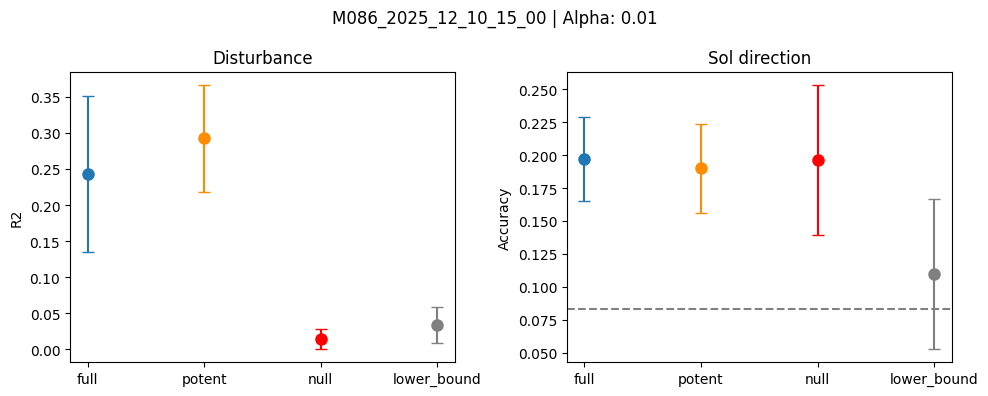

In [394]:
labels = ['full', 'potent', 'null', 'lower_bound']
clrs   = ['tab:blue', 'darkorange', 'red', 'gray']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

data = [
    (axs[0], 'Disturbance', [r2s_full, r2s_potent, r2s_null, r2s_lower_bound], 'R2', ),
    (axs[1], 'Sol direction', [r2s_full_dir, r2s_potent_dir, r2s_null_dir, r2s_lower_bound_dir], 'Accuracy'),
]

for ax, title, r2s_list, ylabel in data:
    for i, (lbl, r2s, c) in enumerate(zip(labels, r2s_list, clrs)):
        ax.errorbar(i, r2s.mean(), yerr=r2s.std(), color=c, fmt='o', markersize=8, capsize=4, label=lbl)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel=='Accuracy':
        ax.axhline(1/12, color='gray', linestyle='dashed')
plt.suptitle(f'{SESSIONS[0]} | Alpha: {alpha}')
plt.tight_layout()